# 2. Exploratory Data Analysis (EDA)  
---

## 2.1 Setup & Load Data

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from scipy import stats

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
sns.set_palette('muted')

df = pd.read_csv('../data/rainfall.csv')
df['datetime'] = pd.to_datetime(df['datetime'], dayfirst=True)
df = df.sort_values('datetime').reset_index(drop=True)
df['year']    = df['datetime'].dt.year
df['month']   = df['datetime'].dt.month
df['quarter'] = df['datetime'].dt.quarter
df['dayofyear'] = df['datetime'].dt.dayofyear

TARGET   = 'temp'
FEATURES = ['dew', 'humidity', 'sealevelpressure',
            'winddir', 'solarradiation', 'windspeed', 'preciptype']

print(f'Dataset  : {df.shape[0]:,} observations  |  {df.shape[1]} variables')
print(f'Period   : {df["datetime"].min().date()}  →  {df["datetime"].max().date()}')
print(f'Target   : {TARGET}  |  Mean={df[TARGET].mean():.2f}°C  Std={df[TARGET].std():.2f}°C')

Dataset  : 1,781 observations  |  14 variables
Period   : 2016-01-01  →  2020-11-15
Target   : temp  |  Mean=28.34°C  Std=1.96°C


## 2.2 Descriptive Statistics of Target Variable

In [4]:
desc = df[TARGET].describe()
extra = pd.Series({
    'skewness' : df[TARGET].skew(),
    'kurtosis' : df[TARGET].kurtosis(),
    'range'    : df[TARGET].max() - df[TARGET].min()
})
print('=== Temperature (°C) — Descriptive Statistics ===')
print(pd.concat([desc, extra]).round(4).to_string())

# Normality test
stat, p = stats.shapiro(df[TARGET].sample(500, random_state=42))
print(f'\nShapiro-Wilk (n=500): W={stat:.4f}, p={p:.4f}')
print('→ Distribution appears', 'NORMAL' if p > 0.05 else 'NON-NORMAL', 'at α=0.05')

=== Temperature (°C) — Descriptive Statistics ===
count       1781.0000
mean          28.3426
std            1.9600
min           20.2000
25%           27.2000
50%           28.5000
75%           29.7000
max           32.8000
skewness      -0.5096
kurtosis       0.1646
range         12.6000

Shapiro-Wilk (n=500): W=0.9806, p=0.0000
→ Distribution appears NON-NORMAL at α=0.05


## 2.3 Distribution of Temperature

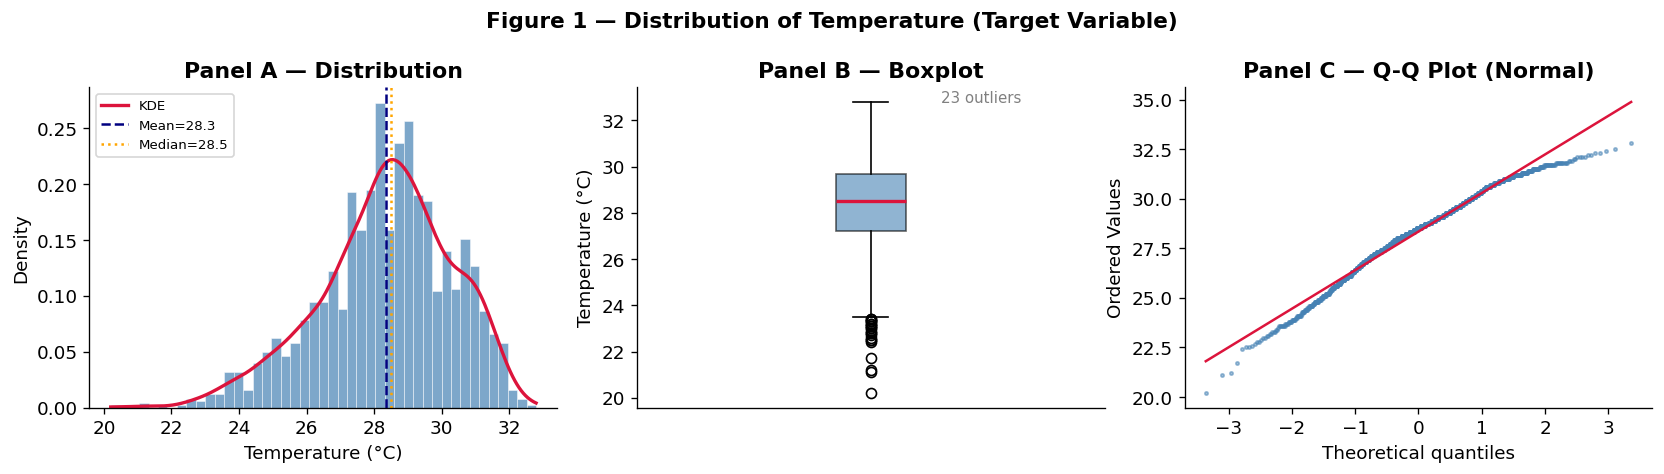

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# --- Panel A: Histogram + KDE ---
axes[0].hist(df[TARGET], bins=45, density=True, alpha=0.7,
             color='steelblue', edgecolor='white', linewidth=0.4)
xmin, xmax = df[TARGET].min(), df[TARGET].max()
x = np.linspace(xmin, xmax, 200)
kde = stats.gaussian_kde(df[TARGET])
axes[0].plot(x, kde(x), color='crimson', linewidth=2, label='KDE')
axes[0].axvline(df[TARGET].mean(),   color='navy',   linestyle='--', lw=1.5, label=f'Mean={df[TARGET].mean():.1f}')
axes[0].axvline(df[TARGET].median(), color='orange',  linestyle=':',  lw=1.5, label=f'Median={df[TARGET].median():.1f}')
axes[0].set_xlabel('Temperature (°C)')
axes[0].set_ylabel('Density')
axes[0].set_title('Panel A — Distribution', fontweight='bold')
axes[0].legend(fontsize=8)

# --- Panel B: Boxplot ---
bp = axes[1].boxplot(df[TARGET], patch_artist=True, vert=True,
                     medianprops=dict(color='crimson', linewidth=2))
bp['boxes'][0].set_facecolor('steelblue')
bp['boxes'][0].set_alpha(0.6)
axes[1].set_ylabel('Temperature (°C)')
axes[1].set_title('Panel B — Boxplot', fontweight='bold')
axes[1].set_xticks([])
# Annotate outliers count
q1, q3 = df[TARGET].quantile(0.25), df[TARGET].quantile(0.75)
iqr = q3 - q1
outliers = df[(df[TARGET] < q1 - 1.5*iqr) | (df[TARGET] > q3 + 1.5*iqr)]
axes[1].text(1.15, df[TARGET].max(), f'{len(outliers)} outliers',
             ha='left', fontsize=9, color='gray')

# --- Panel C: Q-Q Plot ---
stats.probplot(df[TARGET], dist='norm', plot=axes[2])
axes[2].set_title('Panel C — Q-Q Plot (Normal)', fontweight='bold')
axes[2].get_lines()[0].set(markersize=2, alpha=0.5, color='steelblue')
axes[2].get_lines()[1].set(color='crimson', linewidth=1.5)

fig.suptitle('Figure 1 — Distribution of Temperature (Target Variable)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig1_temp_distribution.png', bbox_inches='tight')
plt.show()

## 2.4 Time Series Plot with Trend & Rolling Statistics

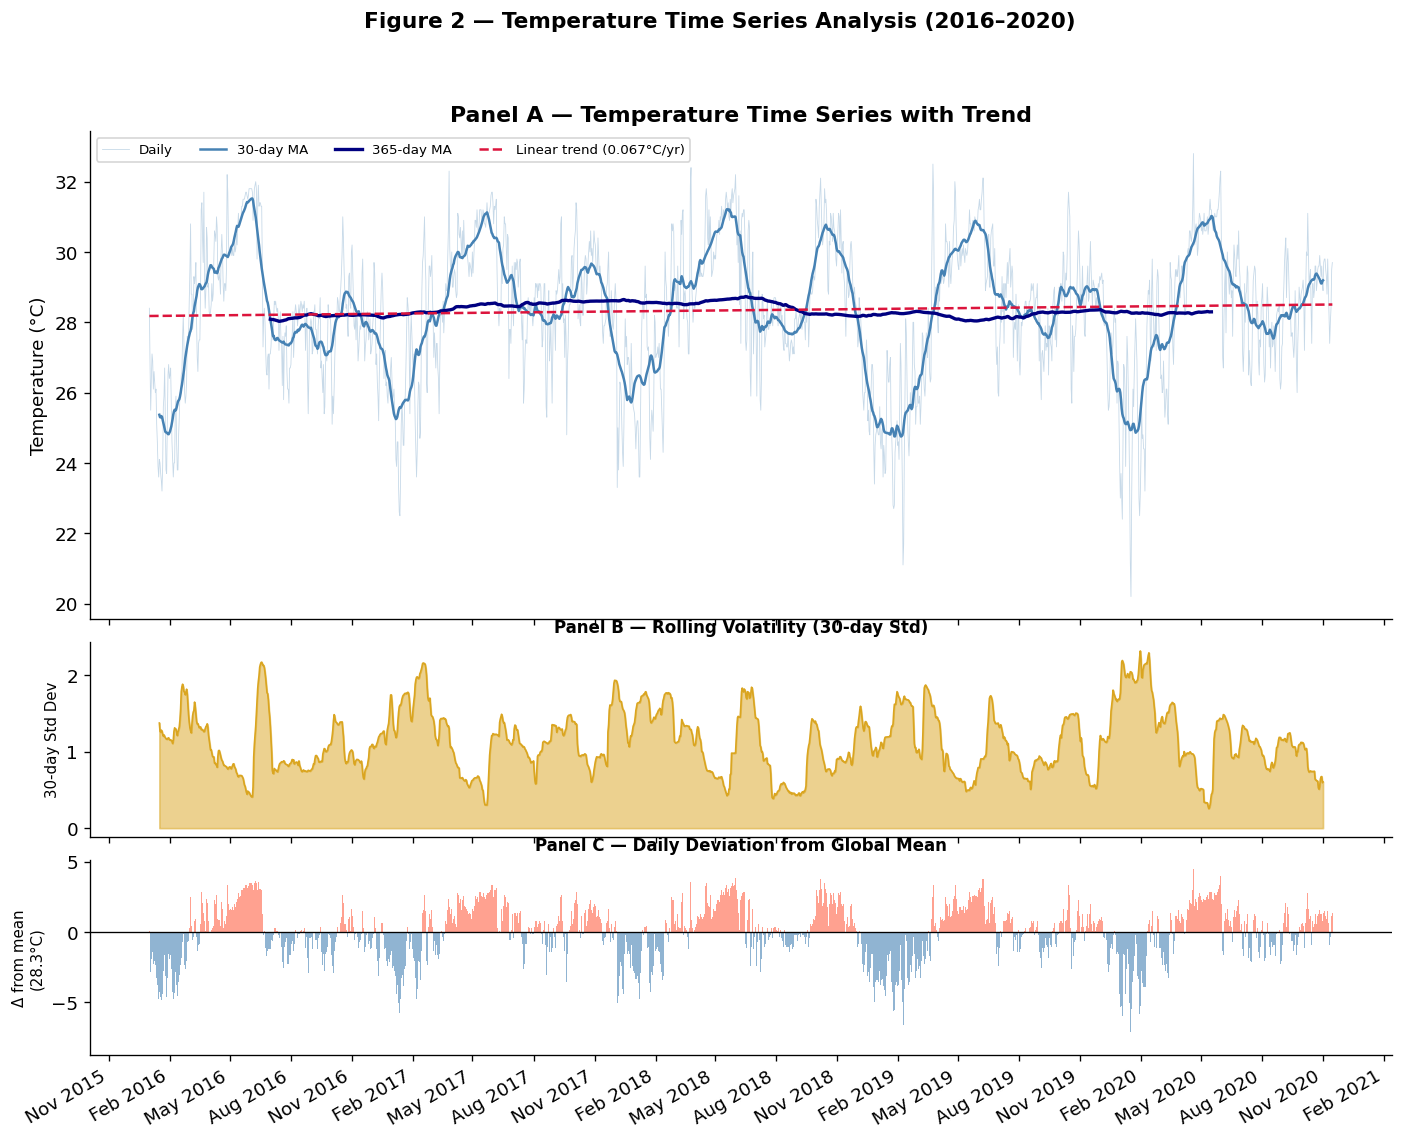

Linear trend : 0.0669 °C/year  |  R²=0.0023  |  p=0.0425


In [6]:
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True,
                          gridspec_kw={'hspace': 0.08, 'height_ratios': [3, 1.2, 1.2]})

# --- Panel A: Raw series + rolling mean + linear trend ---
roll30  = df[TARGET].rolling(30,  center=True).mean()
roll365 = df[TARGET].rolling(365, center=True).mean()
x_num   = np.arange(len(df))
slope, intercept, r, p, se = stats.linregress(x_num, df[TARGET])
trend_line = slope * x_num + intercept

axes[0].plot(df['datetime'], df[TARGET],    color='steelblue', alpha=0.3, linewidth=0.5, label='Daily')
axes[0].plot(df['datetime'], roll30,        color='steelblue', linewidth=1.5, label='30-day MA')
axes[0].plot(df['datetime'], roll365,       color='navy',      linewidth=2.0, label='365-day MA')
axes[0].plot(df['datetime'], trend_line,    color='crimson',   linewidth=1.5,
             linestyle='--', label=f'Linear trend ({slope*365:.3f}°C/yr)')
axes[0].set_ylabel('Temperature (°C)')
axes[0].set_title('Panel A — Temperature Time Series with Trend', fontweight='bold')
axes[0].legend(fontsize=8, ncol=4)

# --- Panel B: Rolling standard deviation (volatility) ---
roll_std = df[TARGET].rolling(30, center=True).std()
axes[1].fill_between(df['datetime'], roll_std, alpha=0.5, color='goldenrod')
axes[1].plot(df['datetime'], roll_std, color='goldenrod', linewidth=1)
axes[1].set_ylabel('30-day Std Dev', fontsize=9)
axes[1].set_title('Panel B — Rolling Volatility (30-day Std)', fontweight='bold', fontsize=10)

# --- Panel C: Year-over-year deviation from global mean ---
global_mean = df[TARGET].mean()
deviation   = df[TARGET] - global_mean
colors_dev  = ['tomato' if v >= 0 else 'steelblue' for v in deviation]
axes[2].bar(df['datetime'], deviation, color=colors_dev, alpha=0.6, width=1)
axes[2].axhline(0, color='black', linewidth=0.8)
axes[2].set_ylabel(f'Δ from mean\n({global_mean:.1f}°C)', fontsize=9)
axes[2].set_title('Panel C — Daily Deviation from Global Mean', fontweight='bold', fontsize=10)

# X-axis
axes[2].xaxis.set_major_locator(mdates.MonthLocator(interval=3))
axes[2].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.xticks(rotation=30, ha='right')

fig.suptitle('Figure 2 — Temperature Time Series Analysis (2016–2020)',
             fontsize=13, fontweight='bold')
plt.savefig('fig2_time_series_temp.png', bbox_inches='tight')
plt.show()

print(f'Linear trend : {slope*365:.4f} °C/year  |  R²={r**2:.4f}  |  p={p:.4f}')



Nhìn vào **Panel A**, chuỗi nhiệt độ ngày có hai đặc điểm nổi bật.
Thứ nhất, đường 365-day MA gần như nằm ngang quanh 28°C, xác nhận
xu hướng tuyến tính rất yếu (+0.067°C/năm). Thứ hai, đường 30-day
MA dao động mạnh và lặp lại theo chu kỳ năm — bằng chứng trực quan
rõ ràng cho tính mùa vụ (*seasonality*).

**Panel B** cho thấy độ biến động (30-day Std) tập trung ở mức
1.0–2.3°C, cao nhất vào đầu năm (tháng 1–3) khi chuyển tiếp giữa
mùa khô và mùa nóng. Giai đoạn mùa mưa (tháng 6–9) volatility
thấp hơn, phản ánh nhiệt độ ổn định hơn trong mùa này.

**Panel C** cho thấy độ lệch so với trung bình toàn chuỗi (28.3°C)
phân bố không đối xứng: các ngày lạnh hơn trung bình (màu xanh) có
độ lệch âm lên đến **−8°C** (tháng 1–2), trong khi các ngày nóng
hơn trung bình chỉ lệch dương tối đa **+4°C**. Điều này nhất quán
với hệ số skewness âm (−0.51) quan sát được ở phần phân phối.

## 2.5 Seasonality — Monthly & Quarterly Patterns

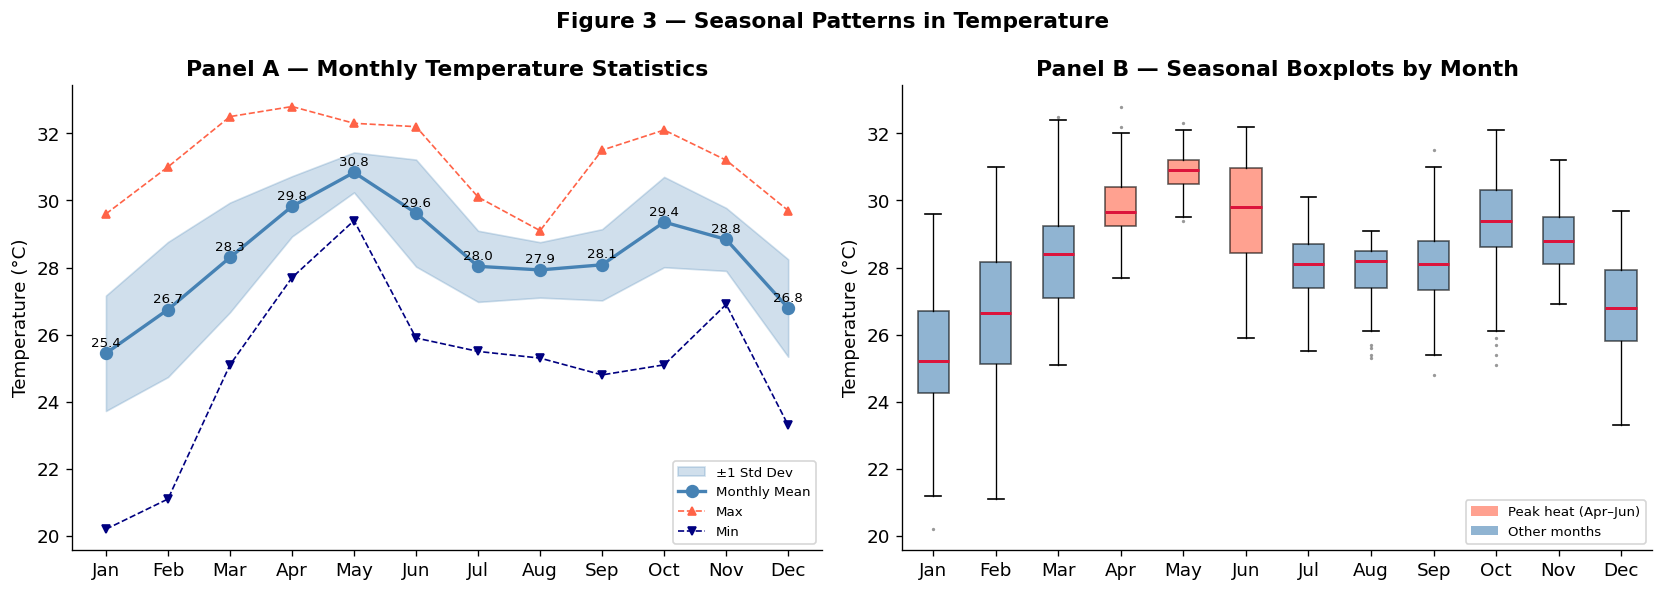

        mean   std   min   max
month                         
1      25.44  1.72  20.2  29.6
2      26.75  2.01  21.1  31.0
3      28.30  1.64  25.1  32.5
4      29.82  0.90  27.7  32.8
5      30.84  0.60  29.4  32.3
6      29.62  1.60  25.9  32.2
7      28.04  1.06  25.5  30.1
8      27.93  0.83  25.3  29.1
9      28.08  1.06  24.8  31.5
10     29.36  1.35  25.1  32.1
11     28.84  0.94  26.9  31.2
12     26.79  1.45  23.3  29.7


In [7]:
month_labels = ['Jan','Feb','Mar','Apr','May','Jun',
                'Jul','Aug','Sep','Oct','Nov','Dec']
monthly_stats = df.groupby('month')[TARGET].agg(['mean','std','min','max'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Panel A: Monthly mean + std band ---
months = monthly_stats.index
means  = monthly_stats['mean']
stds   = monthly_stats['std']
axes[0].fill_between(months, means - stds, means + stds,
                     alpha=0.25, color='steelblue', label='±1 Std Dev')
axes[0].plot(months, means, color='steelblue', marker='o',
             linewidth=2, markersize=7, label='Monthly Mean')
axes[0].plot(months, monthly_stats['max'], color='tomato',
             linestyle='--', linewidth=1, marker='^', markersize=5, label='Max')
axes[0].plot(months, monthly_stats['min'], color='navy',
             linestyle='--', linewidth=1, marker='v', markersize=5, label='Min')
for m, v in zip(months, means):
    axes[0].text(m, v + 0.2, f'{v:.1f}', ha='center', fontsize=8)
axes[0].set_xticks(months)
axes[0].set_xticklabels(month_labels)
axes[0].set_ylabel('Temperature (°C)')
axes[0].set_title('Panel A — Monthly Temperature Statistics', fontweight='bold')
axes[0].legend(fontsize=8)

# --- Panel B: Boxplot by month (seasonal pattern) ---
data_by_month = [df[df['month'] == m][TARGET].values for m in range(1, 13)]
bp = axes[1].boxplot(data_by_month, patch_artist=True,
                     medianprops=dict(color='crimson', linewidth=1.8),
                     whiskerprops=dict(linewidth=0.8),
                     flierprops=dict(marker='.', markersize=2, alpha=0.4))
# Color hot months (Apr–Jun) differently
hot_months = {4, 5, 6}
for i, patch in enumerate(bp['boxes']):
    patch.set_facecolor('tomato' if (i+1) in hot_months else 'steelblue')
    patch.set_alpha(0.6)
axes[1].set_xticklabels(month_labels)
axes[1].set_ylabel('Temperature (°C)')
axes[1].set_title('Panel B — Seasonal Boxplots by Month', fontweight='bold')

from matplotlib.patches import Patch
axes[1].legend(handles=[
    Patch(facecolor='tomato',   alpha=0.6, label='Peak heat (Apr–Jun)'),
    Patch(facecolor='steelblue',alpha=0.6, label='Other months')
], fontsize=8)

fig.suptitle('Figure 3 — Seasonal Patterns in Temperature',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig3_seasonality.png', bbox_inches='tight')
plt.show()

print(monthly_stats.round(2).to_string())


**Panel A** xác nhận cấu trúc mùa vụ rõ ràng hai đỉnh:
- **Đỉnh nhiệt tháng 5** (30.8°C) — cuối mùa khô nóng, bức xạ mặt
  trời cao, độ ẩm thấp
- **Đáy nhiệt tháng 1** (25.4°C) — mùa khô mát, chênh lệch so với
  đỉnh là **5.4°C**

Đường Max (màu đỏ) cho thấy nhiệt độ cực đại có thể vượt 32°C ở
hầu hết các tháng trong năm, trong khi Min giảm mạnh xuống dưới
21°C vào tháng 1–2 — đây chính là nguồn gốc của các outlier được
phát hiện trong bước preprocessing.

**Panel B** (boxplot theo tháng) bổ sung thêm thông tin về phân
phối nội tháng. Tháng 4–6 (màu đỏ — peak heat) có IQR hẹp và
median cao ~30°C, cho thấy nhiệt độ ổn định ở mức cao. Ngược lại,
tháng 1–2 có IQR rộng hơn, phản ánh biến động lớn hơn trong mùa
lạnh. Các outlier (chấm xám) tập trung ở tháng 1, 2, 12 — nhất
quán với nhận định từ bước outlier detection.

> **Implication cho model:** Seasonality rõ ràng với chu kỳ 12
> tháng → cần tham số mùa vụ (P, D, Q, s=12) trong SARIMA.

## 2.6 Autocorrelation Analysis (ACF)

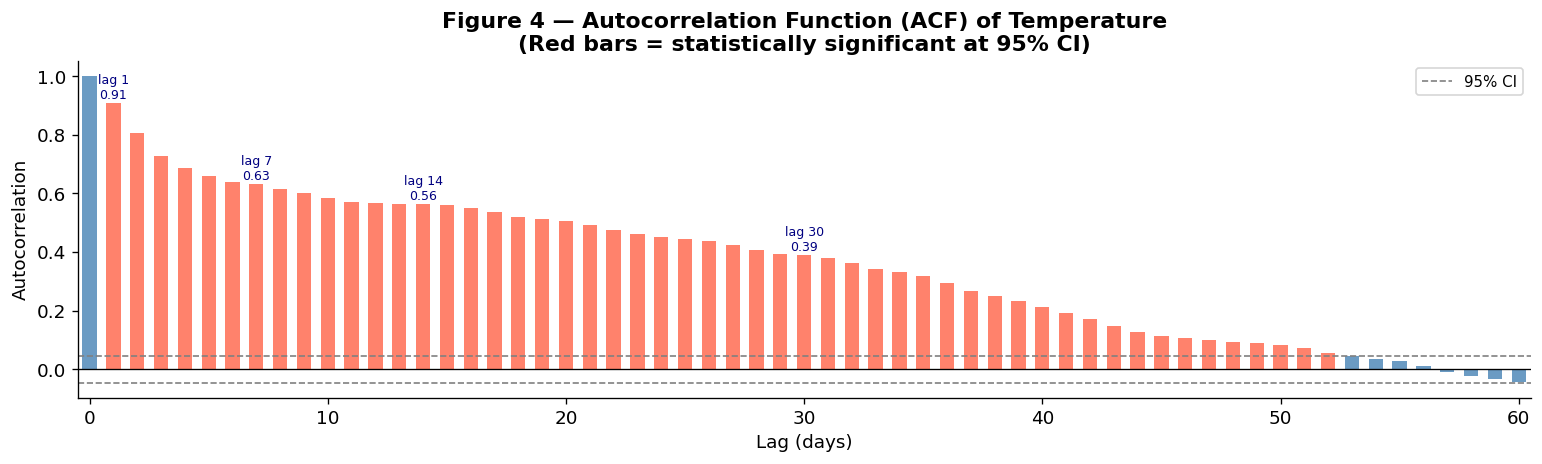

ACF lag-1  : 0.9085  (strong positive autocorrelation)
ACF lag-7  : 0.6314
ACF lag-30 : 0.3890
95% CI band: ±0.0464


In [8]:
def manual_acf(series, nlags=40):
    """Compute ACF without statsmodels."""
    s    = series.values
    mean = s.mean()
    var  = ((s - mean) ** 2).mean()
    acf_vals = [1.0]
    for k in range(1, nlags + 1):
        cov = ((s[:-k] - mean) * (s[k:] - mean)).mean()
        acf_vals.append(cov / var)
    return np.array(acf_vals)

lags     = 60
acf_vals = manual_acf(df[TARGET], nlags=lags)
conf     = 1.96 / np.sqrt(len(df))   # 95% confidence band

fig, ax = plt.subplots(figsize=(13, 4))
lag_range = np.arange(0, lags + 1)
ax.bar(lag_range, acf_vals, color=[
    'tomato' if abs(v) > conf and i > 0 else 'steelblue'
    for i, v in enumerate(acf_vals)
], alpha=0.8, width=0.6)
ax.axhline( conf, color='gray', linestyle='--', linewidth=1, label='95% CI')
ax.axhline(-conf, color='gray', linestyle='--', linewidth=1)
ax.axhline(0,     color='black', linewidth=0.8)
ax.set_xlabel('Lag (days)')
ax.set_ylabel('Autocorrelation')
ax.set_title('Figure 4 — Autocorrelation Function (ACF) of Temperature\n'
             '(Red bars = statistically significant at 95% CI)', fontweight='bold')
ax.legend(fontsize=9)
ax.set_xlim(-0.5, lags + 0.5)

# Annotate key lags
for lag in [1, 7, 14, 30]:
    ax.text(lag, acf_vals[lag] + 0.015, f'lag {lag}\n{acf_vals[lag]:.2f}',
            ha='center', fontsize=7.5, color='navy')

plt.tight_layout()
plt.savefig('fig4_acf.png', bbox_inches='tight')
plt.show()

print(f'ACF lag-1  : {acf_vals[1]:.4f}  (strong positive autocorrelation)')
print(f'ACF lag-7  : {acf_vals[7]:.4f}')
print(f'ACF lag-30 : {acf_vals[30]:.4f}')
print(f'95% CI band: ±{conf:.4f}')


ACF của chuỗi `temp` giảm chậm và có ý nghĩa thống kê
(vượt ngưỡng 95% CI) đến tận lag 55, đây là dấu hiệu điển hình
của chuỗi **không dừng** (*non-stationary*) với cấu trúc tự tương
quan mạnh.

Các giá trị ACF đáng chú ý:

| Lag | ACF | Diễn giải |
|-----|-----|-----------|
| 1   | 0.91 | Rất mạnh — nhiệt độ hôm nay phụ thuộc cao vào hôm qua |
| 7   | 0.63 | Còn mạnh — tín hiệu tuần |
| 14  | 0.56 | Trung bình — tín hiệu hai tuần |
| 30  | 0.39 | Yếu dần — tín hiệu tháng |
| 55+ | ≈ 0  | Không còn ý nghĩa thống kê |

Dạng ACF giảm dần tuyến tính (không cắt xuống 0 đột ngột) gợi ý
nên dùng **d=1** (lấy sai phân bậc 1) để đưa chuỗi về dạng dừng
trước khi fit SARIMA. Sau sai phân bậc 1, ACF lag-1 giảm từ 0.91
xuống 0.056 — xác nhận d=1 là đủ.

## 2.7 Correlation between Temperature and Predictors

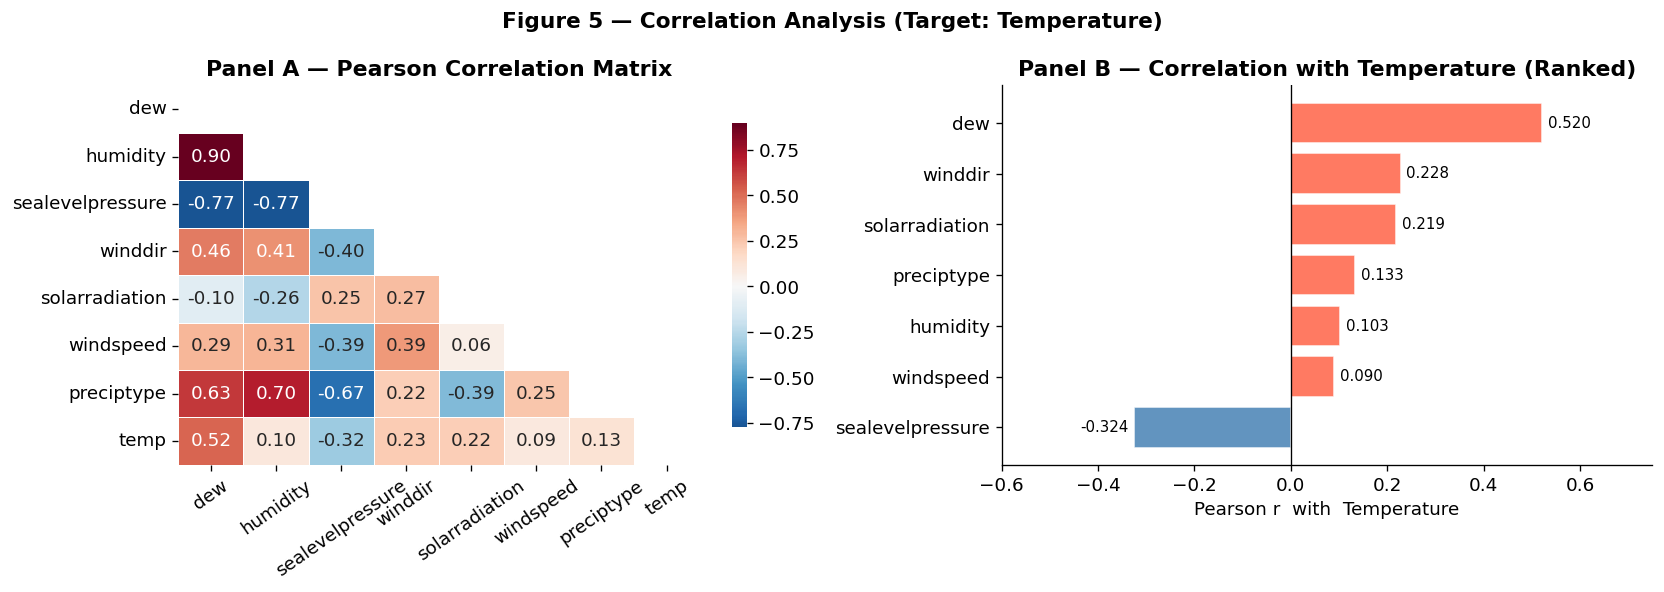


=== Pearson r with Temperature (sorted) ===
sealevelpressure   -0.3244
windspeed           0.0897
humidity            0.1027
preciptype          0.1332
solarradiation      0.2186
winddir             0.2279
dew                 0.5205


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Panel A: Heatmap ---
all_cols = FEATURES + [TARGET]
corr     = df[all_cols].corr()
mask     = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, linewidths=0.5, ax=axes[0],
            cbar_kws={'shrink': 0.8})
axes[0].set_title('Panel A — Pearson Correlation Matrix', fontweight='bold')
axes[0].tick_params(axis='x', rotation=35)

# --- Panel B: Correlation with temp (ranked bar) ---
corr_target = df[all_cols].corr()[TARGET].drop(TARGET).sort_values()
colors = ['tomato' if v > 0 else 'steelblue' for v in corr_target]
bars = axes[1].barh(corr_target.index, corr_target.values,
                    color=colors, edgecolor='white', alpha=0.85)
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].set_xlabel('Pearson r  with  Temperature')
axes[1].set_title('Panel B — Correlation with Temperature (Ranked)', fontweight='bold')
for bar, val in zip(bars, corr_target.values):
    axes[1].text(val + (0.012 if val >= 0 else -0.012),
                 bar.get_y() + bar.get_height()/2,
                 f'{val:.3f}', va='center',
                 ha='left' if val >= 0 else 'right', fontsize=9)
axes[1].set_xlim(-0.6, 0.75)

fig.suptitle('Figure 5 — Correlation Analysis (Target: Temperature)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig5_correlation.png', bbox_inches='tight')
plt.show()

print('\n=== Pearson r with Temperature (sorted) ===')
print(corr_target.round(4).to_string())

## 2.8 Scatter Plots — Top Predictors vs Temperature

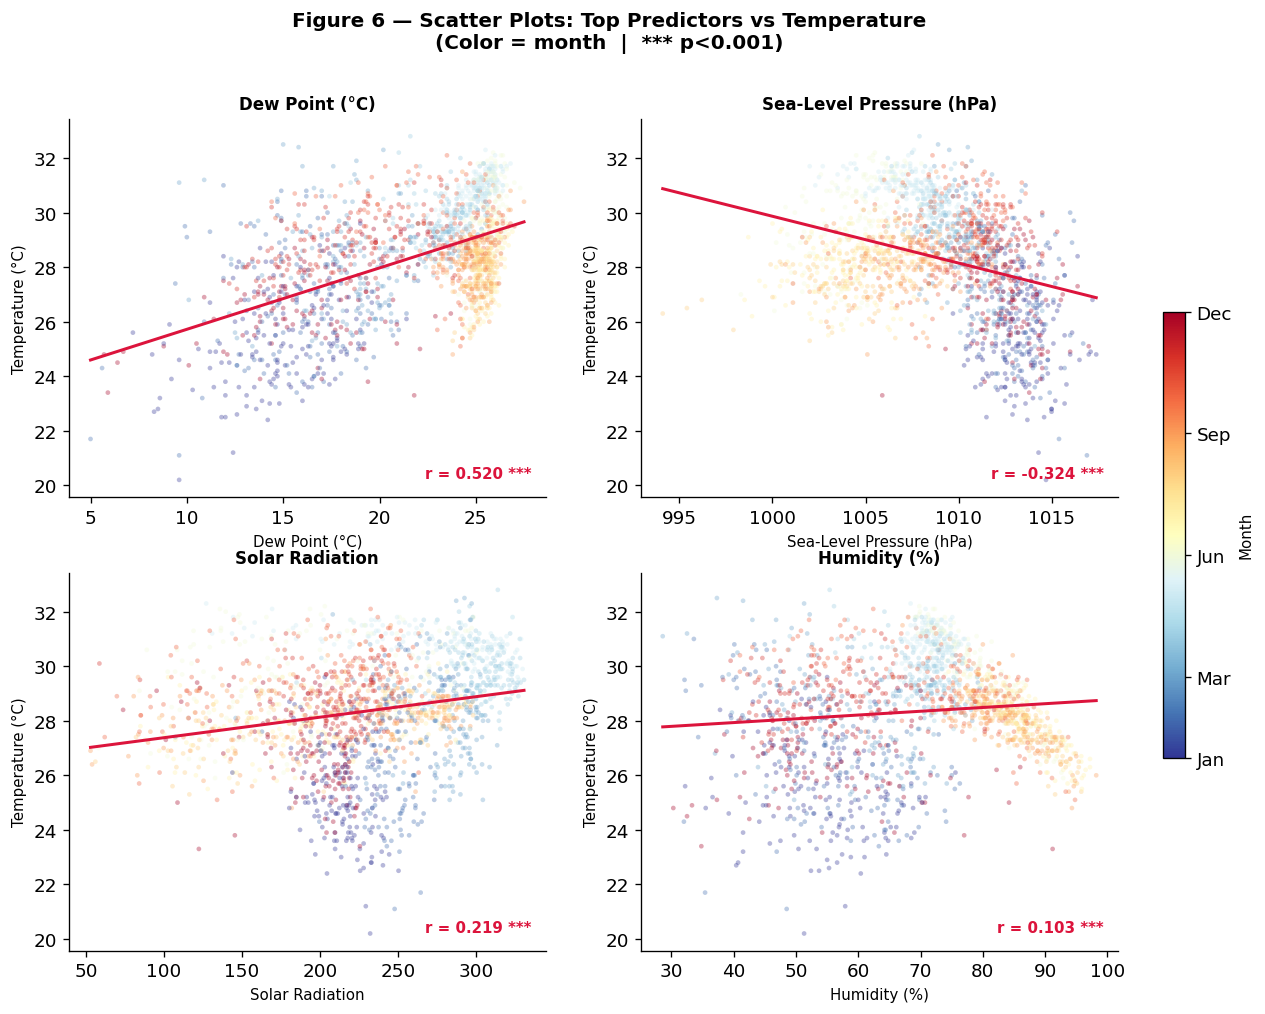

In [10]:
top_predictors = ['dew', 'sealevelpressure', 'solarradiation', 'humidity']
pred_labels    = {
    'dew'             : 'Dew Point (°C)',
    'sealevelpressure': 'Sea-Level Pressure (hPa)',
    'solarradiation'  : 'Solar Radiation',
    'humidity'        : 'Humidity (%)'
}

fig, axes = plt.subplots(2, 2, figsize=(12, 9))
axes = axes.flatten()

for ax, col in zip(axes, top_predictors):
    r, p = stats.pearsonr(df[col], df[TARGET])
    ax.scatter(df[col], df[TARGET],
               c=df['month'], cmap='RdYlBu_r',
               alpha=0.35, s=8, edgecolors='none')
    # Regression line
    m, b = np.polyfit(df[col], df[TARGET], 1)
    x_line = np.linspace(df[col].min(), df[col].max(), 100)
    ax.plot(x_line, m*x_line + b, color='crimson', linewidth=1.8)
    ax.set_xlabel(pred_labels[col], fontsize=9)
    ax.set_ylabel('Temperature (°C)', fontsize=9)
    ax.set_title(f'{pred_labels[col]}', fontweight='bold', fontsize=10)
    sig = '***' if p < 0.001 else ('**' if p < 0.01 else '*')
    ax.text(0.97, 0.05, f'r = {r:.3f} {sig}',
            transform=ax.transAxes, ha='right', fontsize=9,
            color='crimson', fontweight='bold')

# Colorbar for month
sm = plt.cm.ScalarMappable(cmap='RdYlBu_r',
                            norm=plt.Normalize(vmin=1, vmax=12))
cbar = fig.colorbar(sm, ax=axes, orientation='vertical',
                    fraction=0.02, pad=0.04, shrink=0.6)
cbar.set_label('Month', fontsize=9)
cbar.set_ticks([1, 3, 6, 9, 12])
cbar.set_ticklabels(['Jan','Mar','Jun','Sep','Dec'])

fig.suptitle('Figure 6 — Scatter Plots: Top Predictors vs Temperature\n'
             '(Color = month  |  *** p<0.001)',
             fontsize=12, fontweight='bold')
plt.savefig('fig6_scatter_predictors.png', bbox_inches='tight')
plt.show()

## 2.9 Yearly Trend Analysis

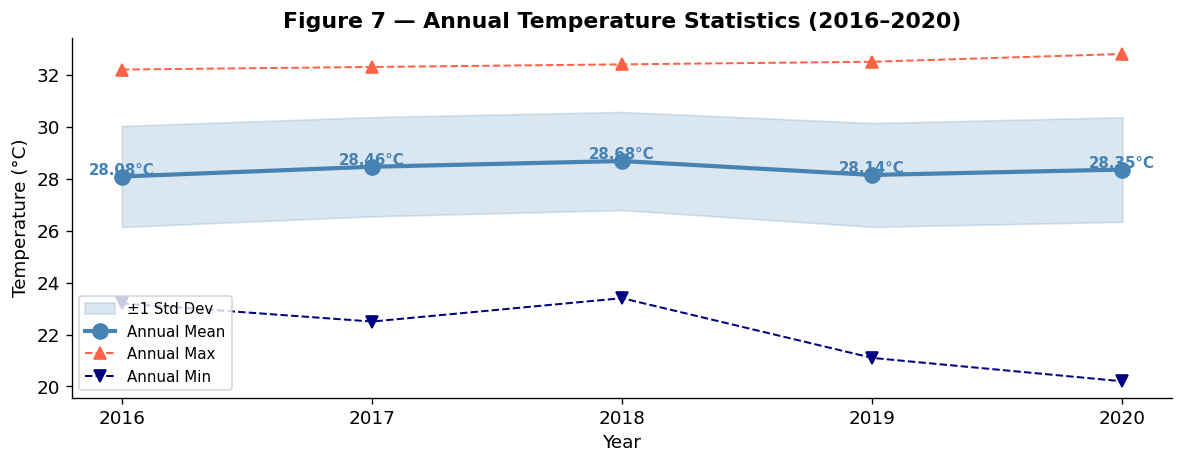

 year   mean   std  min  max
 2016 28.083 1.943 23.2 32.2
 2017 28.459 1.910 22.5 32.3
 2018 28.679 1.889 23.4 32.4
 2019 28.143 1.999 21.1 32.5
 2020 28.351 2.012 20.2 32.8


In [11]:
yearly = df.groupby('year')[TARGET].agg(['mean','std','min','max']).reset_index()

fig, ax = plt.subplots(figsize=(10, 4))
ax.fill_between(yearly['year'],
                yearly['mean'] - yearly['std'],
                yearly['mean'] + yearly['std'],
                alpha=0.2, color='steelblue', label='±1 Std Dev')
ax.plot(yearly['year'], yearly['mean'], color='steelblue',
        marker='o', linewidth=2.5, markersize=9, label='Annual Mean')
ax.plot(yearly['year'], yearly['max'], color='tomato',
        marker='^', linestyle='--', linewidth=1.2, markersize=7, label='Annual Max')
ax.plot(yearly['year'], yearly['min'], color='navy',
        marker='v', linestyle='--', linewidth=1.2, markersize=7, label='Annual Min')

for _, row in yearly.iterrows():
    ax.text(row['year'], row['mean'] + 0.08, f"{row['mean']:.2f}°C",
            ha='center', fontsize=9, color='steelblue', fontweight='bold')

ax.set_xticks(yearly['year'])
ax.set_xlabel('Year')
ax.set_ylabel('Temperature (°C)')
ax.set_title('Figure 7 — Annual Temperature Statistics (2016–2020)',
             fontweight='bold')
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('fig7_yearly_trend.png', bbox_inches='tight')
plt.show()

print(yearly.round(3).to_string(index=False))


Nhiệt độ trung bình năm dao động trong biên độ hẹp
(**28.08°C – 28.68°C**), không có xu hướng tăng hoặc giảm rõ ràng
qua 5 năm quan sát. Điều này nhất quán với hệ số góc xu hướng
tuyến tính rất nhỏ (+0.067°C/năm, R²≈0.002).

Đáng chú ý hơn là **Annual Min** có xu hướng giảm dần từ 2018 đến
2020 (từ 23.4°C xuống 20.2°C) — phản ánh các đợt lạnh bất thường
ngày càng sâu hơn trong giai đoạn cuối chuỗi. Ngược lại,
**Annual Max** gần như không thay đổi (~32.2–32.8°C), cho thấy
ngưỡng nhiệt tối đa tương đối ổn định.

> **Implication cho model:** Không cần detrending — trend quá yếu
> để ảnh hưởng đến model. Tuy nhiên sai phân bậc 1 (d=1) vẫn cần
> thiết để xử lý autocorrelation, không phải để loại trend.

## 2.10 EDA Summary

| Finding | Detail |
|---|---|
| **Range** | 20.2°C – 32.8°C, Mean = 28.3°C, Std = 1.96°C |
| **Distribution** | Slightly left-skewed (−0.51), near-normal |
| **Seasonal peak** | Apr–Jun hottest (~30–31°C); Jan coldest (~25°C) |
| **Linear trend** | +0.067°C/year (weak warming signal) |
| **Autocorrelation** | Very high at lag-1 (r=0.91) → strong time dependency |
| **Top predictor** | Dew point (r=0.52), Sea-level pressure (r=−0.32) |
| **Implication** | Seasonality + autocorrelation → suitable for ARIMA / SARIMA or regression with lag features |